### Day 1: Understand What Features You Need
  * Research what drives wildfire spread - wind, slope, vegetation, humidity, temperature
  * Identify which data sources provide each features
  * Plan your feature engineering approach

#### How wildfires start
  * Three elements are needed for a fire to start:
    * fuel (wood. brush, lichen)
    * oxygen (from the air)
    * ignition source (heat from lightning or human activities)
  
#### How wildfires spread?
  * The primary factors that influence the spread of wildfires are
    * Fuels
    * Weather
    * Topography (what the landscape in the area is like)

* Fuel - Vegetation type and density - what's available to burn - MODIS Land Cover or ESA WorldCover
* Weather - Wind speed, wind direction, temperature, humidity - Open Meteo API
* Topography - Elevation and slope - fire moves faster uphill - USGS or NASA SRTM elevation data

### Day 2: Get Weather Data
  * Sign up for the Open-Meto API - free, no API key required
  * Pull historical weather data for your Canadian wildfire case study location
  * Key variables: wind speed, wind direction, temperature, humidity

In [1]:
import requests
import pandas as pd

In [2]:
# temperature_2m - air temperature at 2 meters above the ground in degrees Celsius
# Higher temperatures dry out vegetation and accelerate spread.

# relative_humidity_2m - relative humidity at 2 meters above ground as a percentage
# Lower humidity means drier fuel which burns faster
latitude = 59.9
longitude = -119.8
url = f"https://archive-api.open-meteo.com/v1/archive?latitude={latitude}&longitude={longitude}&start_date=2023-08-21&end_date=2023-09-30&hourly=temperature_2m,relative_humidity_2m,wind_speed_10m,wind_direction_10m"

In [3]:
response = requests.get(url, timeout=60).json()

In [4]:
hourly = response['hourly']

In [5]:
weather_df = pd.DataFrame(hourly)

In [6]:
weather_df['time'] = pd.to_datetime(weather_df['time'])

In [7]:
weather_df.head()

,time,temperature_2m,relative_humidity_2m,wind_speed_10m,wind_direction_10m
0,2023-08-21 00:00:00,23.3,28,14.1,220
1,2023-08-21 01:00:00,22.2,29,12.2,225
2,2023-08-21 02:00:00,20.7,39,6.9,227
3,2023-08-21 03:00:00,18.2,48,8.0,198
4,2023-08-21 04:00:00,16.6,54,11.4,204


In [8]:
weather_df.to_csv("../data/weather_data.csv", index=False)

### Day 3: Get Terrain Data
  * Download elevation data for your case study region
  * Calculate slope from elevation - fire moves faster uphill
  * Source: USGS National Elevation Dataset or NASA SRTM

In [9]:
# Step 1 - Define Your Bounding Box
  # You need to tell the elevation library which geographic area to download data for. Your bounding box is the rectangular region around your 
  # Canadian wildfire case study:
  # South boundary: latitude 58
  # North boundary: latitude 62
  # West boundary: longitude -122
  # East boundary: longitude -118

In [10]:
south_boundary, north_boundary, west_boundary, east_boundary = 59, 61, -121, -119

In [11]:
# Step 2 - Load your API key securely
  # using dotenv to read it from your .env file instead of hardcoding it

In [12]:
from dotenv import load_dotenv
import os

load_dotenv()
api_key = os.getenv('OPENTOPOGRAPHY_API_KEY')

In [13]:
# Step 3 - Call the OpenTopography API
  # pass your bounding box and API key as parameters using requests, same pattern as your Open-Meteo call

In [14]:
import requests

In [15]:
query_params = {
  "demtype": "SRTMGL1",
  "south": south_boundary,
  "north": north_boundary,
  "west": west_boundary,
  "east": east_boundary,
  "outputFormat": "GTiff",
  "API_Key": api_key
}

In [16]:
response = requests.get(url="https://portal.opentopography.org/API/globaldem", params=query_params)

In [17]:
# Step 4 - Save the response as a GeoTIFF file
  # the API returns raw binary data that you write directly to ../data/elevation.tif

In [18]:
with open('../data/elevation.tif', "wb") as elevation_data_file:
    elevation_data_file.write(response.content)

In [19]:
# Step 5 - Load the GeoTIFF using rasterio
  # read the elevation values into a NumPy array

In [20]:
import rasterio # an open-source Python library used to read, write, and analyze geospatial raster data

In [21]:
with rasterio.open('../data/elevation.tif') as elevation:
    print(elevation.nodata)
    
    # Read the elevation values from the first band into a NumPy array
    band1 = elevation.read(1)
    
    # Print the shape of the array to confirm it loaded correctly
    print(band1.shape)

-32768.0
(7200, 7200)


In [22]:
import numpy as np

In [23]:
# Convert band1 to float64 first
band1_float = np.array(band1, dtype=float)

In [24]:
(band1_float == elevation.nodata).sum()

np.int64(25920000)

In [25]:
band1_float[band1_float == elevation.nodata] = np.nan

In [26]:
np.isnan(band1_float).sum()

np.int64(25920000)

In [27]:
band1_float

array([[ nan,  nan,  nan, ...,  nan,  nan,  nan],
       [ nan,  nan,  nan, ...,  nan,  nan,  nan],
       [ nan,  nan,  nan, ...,  nan,  nan,  nan],
       ...,
       [641., 641., 641., ..., 373., 372., 372.],
       [641., 641., 642., ..., 372., 371., 371.],
       [641., 641., 642., ..., 371., 371., 371.]], shape=(7200, 7200))

In [28]:
gradient_north_south, gradient_east_west = np.gradient(band1_float) # computing the gradients of how the steep the terrain is across the north south and east west range respectively

In [29]:
gradient_north_south_squared = gradient_north_south ** 2

In [30]:
gradient_east_west_squared = gradient_east_west ** 2

In [31]:
slope = np.sqrt(gradient_north_south_squared + gradient_east_west_squared)

In [32]:
np.nanmin(slope), np.nanmax(slope)

(np.float64(0.0), np.float64(13.583077707206124))

In [33]:
# Step 7 - Visualize
  # Plot both the elevation and slope as heatmaps uisng Matplotlib so you can see the terrain of your case study region visually.
  # Mountainous areas will show up clearly

In [34]:
# Slope - using slope with a YlOrRd colormap
# Plot 2 - Slope
  # A 2D grid where each pixel represents how steep the terrain is at that location. Flat areas will
  # be close to zero. Steep mountain faces will have high values. This is the feature that directly
  # influences how fast fire spreads - steep terrain means faster spread

In [35]:
import matplotlib.pyplot as plt

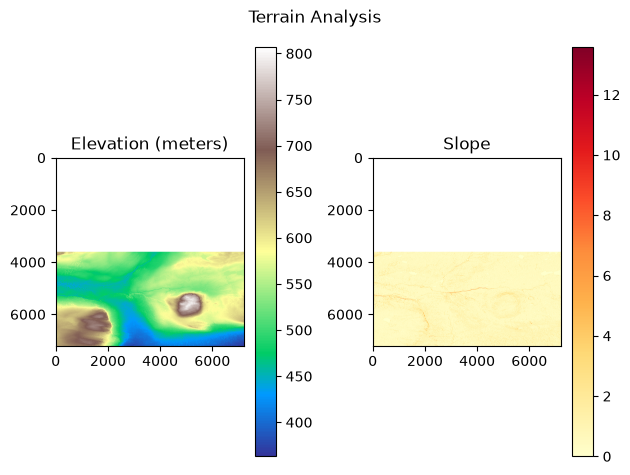

In [36]:
fig, ax = plt.subplots(nrows=1, ncols=2)

# Plotting the elevations of the specified boundary above on a terrain colormap
terrain_color_map = ax[0].imshow(band1_float, cmap='terrain')
plt.colorbar(terrain_color_map) # plotting the range of elevations throughout the specified boundary
ax[0].set_title("Elevation (meters)")

# Plotting the 3D slopes of the terrain across all directions 
slope_color_map = ax[1].imshow(slope, cmap='YlOrRd')
plt.colorbar(slope_color_map) # mostly flat land with very little changes in elevation
ax[1].set_title("Slope")

fig.suptitle("Terrain Analysis")

plt.tight_layout()
plt.show()

In [37]:
# Step 8 - Save both the elevation and slope arrays so you can merge them with your fire detection
np.save('../data/elevation.npy', band1_float)
np.save('../data/slope.npy', slope)

### Day 4: Get Vegetation Data
  * Download land cover / vegetation type data
  * Source: ESA WorldCover
  * Different vegetation types burn at different rates and intensities

In [38]:
# 1, Sign up for the Copernicus Data Space at dataspace.copernicus.eu - free acount, gives you access to ESA datasets
# 2. Find the WorldCover tile covering your bounding box
# 3. Download the GeoTIFF for that tile
# 4. Load it with rasterio - same approach as your elevation data
# 5. Visualize it - each pixel value represents a land cover class
# 6. Save it as a .npy file for merging later

In [39]:
# The vegetation.tif contains a 2D grid where every pizel represents a land cover classification for a 10x10 meter area on the ground.
# Each pixel has a numeric value that corresponds to one of 11 land cover types:
  # 10 - Trees
  # 20 - Shrubland
  # 30 - Grassland
  # 40 - Cropland
  # 50 - Built-up areas
  # 60 - Bare/sparse vegetation
  # 70 - Snow and ice
  # 80 - Permanent water bodies
  # 90 - Herbaceous wetland
  # 100 - Moss and lichen

In [40]:
# 1. Merge the three vegetation tiles

# Open all three tiles with nested with rasterio.open() statements and call merge() to get merged_array and merged_transform. Squeeze to 2D.

In [41]:
import rasterio

In [42]:
from rasterio.merge import merge

In [43]:
with rasterio.open('../data/ESA_WorldCover_10m_2021_v200_N57W123_Map.tif') as vegetation_south:
  with rasterio.open('../data/ESA_WorldCover_10m_2021_v200_N60W120_Map.tif') as vegetation_east:
    with rasterio.open('../data/ESA_WorldCover_10m_2021_v200_N60W123_Map.tif') as vegetation:
      merged_array, merged_transform = merge([vegetation, vegetation_east, vegetation_south])

In [44]:
merged = merged_array[0]

In [45]:
# 2. Clip to your bounding box

# Use rowcol() with merged_transform to get vegetation_row_start, vegetation_column_start, vegetation_row_end, vegetation_column_end using your boundary variables. 
# Slice merged to get vegetation_clipped with shape (24000, 24000).

In [46]:
vegetation_row_start, vegetation_column_start = rasterio.transform.rowcol(merged_transform, west_boundary, north_boundary)
vegetation_row_end, vegetation_column_end = rasterio.transform.rowcol(merged_transform, east_boundary, south_boundary)

In [47]:
vegetation_row_start, vegetation_column_start, vegetation_row_end, vegetation_column_end

(np.int32(24000), np.int32(24000), np.int32(48000), np.int32(48000))

In [48]:
vegetation_clipped = merged[vegetation_row_start:vegetation_row_end, vegetation_column_start:vegetation_column_end]

In [49]:
vegetation_clipped.shape

(24000, 24000)

In [50]:
np.save('../data/vegetation.npy', vegetation_clipped)

In [51]:
# 4. Subtract the offset

# Subtract vegetation_row_start from vegetation_rows and vegetation_column_start from vegetation_cols to get adjusted_rows and adjusted_cols.

In [52]:
# 5. Clip to valid bounds

# Clip both to 0 and 23,999

In [53]:
# 6. Look up and add to dataframe

In [54]:
# 7. Resave

# merged_fire_df.to_csv('../data/merged_fire_data.csv', index=False)

### Day 5: Join All Data Sources
  * Merge weather, terrain, and vegetation data onto your fire detection dataframe
  * Each fire detection row should now have wind, slope, and vegetation attributes

In [55]:
# 1. Filtered your cleaned fire dataframe to your case study region - latitude 59-61, longitude -121 to -119, weeks 34 to 30

In [56]:
cleaned_fire_df = pd.read_csv('../data/cleaned_fire_archive.csv')

In [57]:
cleaned_fire_df['acq_date'] = pd.to_datetime(cleaned_fire_df['acq_date'], format="%Y-%m-%d")

In [58]:
cleaned_fire_df['week'] = cleaned_fire_df['acq_date'].dt.isocalendar().week

In [59]:
filtered_clean_fire_df = cleaned_fire_df[(cleaned_fire_df['latitude'].between(59, 61)) & (cleaned_fire_df['longitude'].between(-121, -119)) & (cleaned_fire_df['week'].between(34, 39))]

In [60]:
# 2. Join weather data - match each fire detection to the closest hourly weather reading by timestamp

In [61]:
weather_df = pd.read_csv('../data/weather_data.csv')
weather_df

,time,temperature_2m,relative_humidity_2m,wind_speed_10m,wind_direction_10m
0,2023-08-21 00:00:00,23.3,28,14.1,220
1,2023-08-21 01:00:00,22.2,29,12.2,225
2,2023-08-21 02:00:00,20.7,39,6.9,227
3,2023-08-21 03:00:00,18.2,48,8.0,198
4,2023-08-21 04:00:00,16.6,54,11.4,204
...,...,...,...,...,...
979,2023-09-30 19:00:00,9.2,81,5.8,173
980,2023-09-30 20:00:00,10.3,72,6.9,171
981,2023-09-30 21:00:00,11.0,64,7.6,172
982,2023-09-30 22:00:00,11.4,60,8.9,166


In [62]:
weather_df['time'] = pd.to_datetime(weather_df['time'])

In [63]:
filtered_clean_fire_df['acq_time'] = filtered_clean_fire_df['acq_time'].astype(str)

In [64]:
filtered_clean_fire_df['acq_time'] = filtered_clean_fire_df['acq_time'].str.zfill(4)

In [65]:
filtered_clean_fire_df['acq_time']

1019632    0443
1019643    0443
1019645    0443
1019648    0443
1019649    0443
           ... 
1296929    2108
1296930    2108
1296933    2108
1296934    2108
1297015    2109
Name: acq_time, Length: 4071, dtype: str

In [66]:
filtered_clean_fire_df['acq_date'] = filtered_clean_fire_df['acq_date'].dt.strftime('%Y-%m-%d')

In [67]:
filtered_clean_fire_df['datetime'] = filtered_clean_fire_df['acq_date'] + " " + filtered_clean_fire_df['acq_time']

In [68]:
filtered_clean_fire_df['datetime'] = pd.to_datetime(filtered_clean_fire_df['datetime'])

In [69]:
filtered_clean_fire_df['datetime'] = filtered_clean_fire_df['datetime'].dt.round('h')

In [70]:
filtered_clean_fire_df['datetime']

1019632   2023-08-21 05:00:00
1019643   2023-08-21 05:00:00
1019645   2023-08-21 05:00:00
1019648   2023-08-21 05:00:00
1019649   2023-08-21 05:00:00
                  ...        
1296929   2023-09-23 21:00:00
1296930   2023-09-23 21:00:00
1296933   2023-09-23 21:00:00
1296934   2023-09-23 21:00:00
1297015   2023-09-23 21:00:00
Name: datetime, Length: 4071, dtype: datetime64[us]

In [71]:
filtered_clean_fire_df.head()

,latitude,longitude,brightness,acq_date,acq_time,satellite,confidence,bright_t31,frp,daynight,type,week,datetime
1019632,60.4007,-120.4775,312.8,2023-08-21,0443,Terra,86,282.8,20.0,N,0,34,2023-08-21 05:00:00
1019643,59.9441,-119.5471,329.8,2023-08-21,0443,Terra,100,282.9,40.4,N,0,34,2023-08-21 05:00:00
1019645,59.9373,-119.4737,313.1,2023-08-21,0443,Terra,75,285.4,18.5,N,0,34,2023-08-21 05:00:00
1019648,59.9447,-119.3600,321.8,2023-08-21,0443,Terra,100,283.4,27.0,N,0,34,2023-08-21 05:00:00
1019649,59.9283,-119.3926,335.7,2023-08-21,0443,Terra,100,290.2,48.2,N,0,34,2023-08-21 05:00:00


In [72]:
weather_df = weather_df.rename(columns={'time':'datetime'})

In [73]:
weather_df

,datetime,temperature_2m,relative_humidity_2m,wind_speed_10m,wind_direction_10m
0,2023-08-21 00:00:00,23.3,28,14.1,220
1,2023-08-21 01:00:00,22.2,29,12.2,225
2,2023-08-21 02:00:00,20.7,39,6.9,227
3,2023-08-21 03:00:00,18.2,48,8.0,198
4,2023-08-21 04:00:00,16.6,54,11.4,204
...,...,...,...,...,...
979,2023-09-30 19:00:00,9.2,81,5.8,173
980,2023-09-30 20:00:00,10.3,72,6.9,171
981,2023-09-30 21:00:00,11.0,64,7.6,172
982,2023-09-30 22:00:00,11.4,60,8.9,166


In [74]:
merged_fire_df = pd.merge(filtered_clean_fire_df, weather_df, on='datetime', how='left')

In [75]:
merged_fire_df.shape

(4071, 17)

In [76]:
merged_fire_df.columns.tolist()

['latitude',
 'longitude',
 'brightness',
 'acq_date',
 'acq_time',
 'satellite',
 'confidence',
 'bright_t31',
 'frp',
 'daynight',
 'type',
 'week',
 'datetime',
 'temperature_2m',
 'relative_humidity_2m',
 'wind_speed_10m',
 'wind_direction_10m']

In [77]:
# 3. Join elevation and slope - for each fire detection latitude/longitude, look up the 
# corresponding pixel value in your elevation and slope arrays

In [78]:
# Open your elevation.tif with rasterio and get its transform object
# For each row in merged_fire_df, use rasterio.transform.rowcol() to convert the latitude and longitude to row and column indicies in the elevation array
# Use those indices to look up the elevation value from your band1_float array
# Do the same for your slope array -- same indices, different array
# Add both as new columns to merged_fire_df - call them elevation and slope

In [79]:
import rasterio

In [80]:
with rasterio.open('../data/elevation.tif') as elevation:
    rows, cols = rasterio.transform.rowcol(elevation.transform, merged_fire_df['longitude'], merged_fire_df['latitude'])

In [81]:
np.clip(rows, 0, 7199, out=rows)
np.clip(cols, 0, 7199, out=cols)

array([1881, 5230, 5495, ..., 5004, 4906, 3625],
      shape=(4071,), dtype=int32)

In [82]:
band1_float[rows, cols]

array([ nan, 580., 581., ..., 546., 552.,  nan], shape=(4071,))

In [83]:
slope[rows, cols]

array([       nan, 1.11803399, 0.70710678, ..., 0.70710678, 0.5       ,
              nan], shape=(4071,))

In [84]:
merged_fire_df['elevation'] = band1_float[rows, cols] # add elevation values to the dataframe

In [85]:
merged_fire_df['slope'] = slope[rows, cols] # add slope values to the dataframe

In [86]:
merged_fire_df.head()

,latitude,longitude,brightness,acq_date,acq_time,satellite,confidence,bright_t31,frp,daynight,type,week,datetime,temperature_2m,relative_humidity_2m,wind_speed_10m,wind_direction_10m,elevation,slope
0,60.4007,-120.4775,312.8,2023-08-21,0443,Terra,86,282.8,20.0,N,0,34,2023-08-21 05:00:00,16.2,56,9.7,211,NaN,NaN
1,59.9441,-119.5471,329.8,2023-08-21,0443,Terra,100,282.9,40.4,N,0,34,2023-08-21 05:00:00,16.2,56,9.7,211,580.0,1.118034
2,59.9373,-119.4737,313.1,2023-08-21,0443,Terra,75,285.4,18.5,N,0,34,2023-08-21 05:00:00,16.2,56,9.7,211,581.0,0.707107
3,59.9447,-119.3600,321.8,2023-08-21,0443,Terra,100,283.4,27.0,N,0,34,2023-08-21 05:00:00,16.2,56,9.7,211,584.0,2.061553
4,59.9283,-119.3926,335.7,2023-08-21,0443,Terra,100,290.2,48.2,N,0,34,2023-08-21 05:00:00,16.2,56,9.7,211,585.0,0.707107


In [87]:
vegetation_rows, vegetation_cols = rasterio.transform.rowcol(merged_transform, merged_fire_df['longitude'], merged_fire_df['latitude']) # 3. Look up vegetation for each fire detection

In [88]:
adjusted_rows = vegetation_rows - vegetation_row_start
adjusted_cols = vegetation_cols - vegetation_column_start

In [89]:
adjusted_rows.min(), adjusted_rows.max()

(np.int32(1), np.int32(24000))

In [90]:
adjusted_cols.min(), adjusted_cols.max()

(np.int32(7), np.int32(23961))

In [91]:
np.clip(adjusted_rows, 0, 23999, out=adjusted_rows)
np.clip(adjusted_cols, 0, 23999, out=adjusted_cols)

array([ 6270, 17434, 18315, ..., 16678, 16352, 12082],
      shape=(4071,), dtype=int32)

In [92]:
adjusted_rows.min(), adjusted_rows.max()

(np.int32(1), np.int32(23999))

In [93]:
adjusted_cols.min(), adjusted_cols.max()

(np.int32(7), np.int32(23961))

In [94]:
merged_fire_df['vegetation'] = vegetation_clipped[adjusted_rows, adjusted_cols]

In [95]:
# 5. Check for missing values in the merged dataframe

In [96]:
merged_fire_df.isnull().sum()

latitude                   0
longitude                  0
brightness                 0
acq_date                   0
acq_time                   0
satellite                  0
confidence                 0
bright_t31                 0
frp                        0
daynight                   0
type                       0
week                       0
datetime                   0
temperature_2m             0
relative_humidity_2m       0
wind_speed_10m             0
wind_direction_10m         0
elevation               1268
slope                   1269
vegetation                 0
dtype: int64

In [97]:
merged_fire_df['elevation'] = merged_fire_df['elevation'].fillna(merged_fire_df['elevation'].mean())

In [98]:
merged_fire_df['slope'] = merged_fire_df['slope'].fillna(merged_fire_df['slope'].mean())

In [99]:
merged_fire_df.isnull().sum()

latitude                0
longitude               0
brightness              0
acq_date                0
acq_time                0
satellite               0
confidence              0
bright_t31              0
frp                     0
daynight                0
type                    0
week                    0
datetime                0
temperature_2m          0
relative_humidity_2m    0
wind_speed_10m          0
wind_direction_10m      0
elevation               0
slope                   0
vegetation              0
dtype: int64

In [100]:
# 6. Save the merged dataframe as merged_fire_data.csv in your data/ folder
merged_fire_df.to_csv('../data/merged_fire_data.csv', index=False)

### Day 6: Feature Engineering
  * Create derived features - wind alignment with slope, days since last rain, vegetation dryness index
  * These compound features often matter more than raw variables

#### 1. Wind alignment with slope
  * fire spreads fastest when wind blows uphill. Create a feature that combines wind direction and slope to capture this interaction. 

In [101]:
# 1. Convert wind_direction_10m from degrees to radians using np.deg2rad()
wind_direction_rad = np.deg2rad(merged_fire_df['wind_direction_10m'])

In [102]:
# 2. Calculate the east-west wind component using np.cos() on the radians
east_west_wind = np.cos(wind_direction_rad)

In [103]:
# 3. Calculate the north-south wind component using np.sin() on the radians
north_south_wind = np.sin(wind_direction_rad)

In [104]:
# 4. Multiply the wind speed by each component to get directional wind vectors

In [105]:
east_west_wind_speed = east_west_wind * merged_fire_df['wind_speed_10m']

In [106]:
north_south_wind_speed = north_south_wind * merged_fire_df['wind_speed_10m']

In [107]:
# 5. Multiply those by slope to get a wind-slope alignment score

In [108]:
east_west_wind = east_west_wind_speed * merged_fire_df['slope']
north_south_wind = north_south_wind_speed * merged_fire_df['slope']

In [109]:
wind_slope_alignment = east_west_wind + north_south_wind

In [110]:
# 6. Save the result as a new column called wind_slope_alignment

In [111]:
merged_fire_df['wind_slope_alignment'] = wind_slope_alignment

#### 2. Vapor Pressure Deficit (VPD)
  * a measure of how much moisture the air can still absorb. High VPD means dry conditions that accelerate fire spread. 
  * Calculate it from temperature and relative humidity

In [112]:
# 1. Saturation vapor pressure - the maximum amount of moisture air can hold at a given temperature. 
# Formula: 0.6108 * np.exp(17.27 * T / (T + 237.3)) where T is temperature in Celsius

In [113]:
merged_fire_df.columns.tolist()

['latitude',
 'longitude',
 'brightness',
 'acq_date',
 'acq_time',
 'satellite',
 'confidence',
 'bright_t31',
 'frp',
 'daynight',
 'type',
 'week',
 'datetime',
 'temperature_2m',
 'relative_humidity_2m',
 'wind_speed_10m',
 'wind_direction_10m',
 'elevation',
 'slope',
 'vegetation',
 'wind_slope_alignment']

In [114]:
temperatures = merged_fire_df['temperature_2m']

In [115]:
saturation_vapor_pressure = 0.6108 * np.exp(17.27 * temperatures / (temperatures + 237.3))

In [116]:
# 2. Actual vapor pressure - how much moisture the air actually contains. 
# Formula: saturation vapor pressure multiplied by relative humidity divided by 100

In [117]:
humidity = merged_fire_df['relative_humidity_2m']

In [118]:
actual_vapor_pressure = (saturation_vapor_pressure * humidity) / 100

In [119]:
# 3. VPD - saturation vapor pressure minus actual vapor pressure

In [120]:
merged_fire_df['vpd'] = saturation_vapor_pressure - actual_vapor_pressure

#### 3. Fuel dryness proxy
  * combine temperature and humidity into a single dryness score.
  * Higher temperature and lower humidity means drier fuel.

In [121]:
merged_fire_df['fuel_dryness'] = temperatures / humidity

In [122]:
merged_fire_df['fuel_dryness']

0       0.289286
1       0.289286
2       0.289286
3       0.289286
4       0.289286
          ...   
4066    0.563636
4067    0.563636
4068    0.563636
4069    0.563636
4070    0.563636
Name: fuel_dryness, Length: 4071, dtype: float64

#### 4. Fire spread risk score
  * combine FRP, slope, wind speed, and fuel dryness into a single risk score

In [123]:
merged_fire_df.columns.tolist()

['latitude',
 'longitude',
 'brightness',
 'acq_date',
 'acq_time',
 'satellite',
 'confidence',
 'bright_t31',
 'frp',
 'daynight',
 'type',
 'week',
 'datetime',
 'temperature_2m',
 'relative_humidity_2m',
 'wind_speed_10m',
 'wind_direction_10m',
 'elevation',
 'slope',
 'vegetation',
 'wind_slope_alignment',
 'vpd',
 'fuel_dryness']

In [124]:
fire_radiative_power = merged_fire_df['frp'] # Fire Radiative Power - Energy Output of each Fire Detection

In [125]:
wind_speed_10m = merged_fire_df['wind_speed_10m'] # standard wind speed measured at 10 meters above the ground

In [126]:
slope = merged_fire_df['slope'] # what the 3D slope at every point in the scanned boundary looks like

In [127]:
fuel_dryness = merged_fire_df['fuel_dryness'] 

In [128]:
fire_radiative_power

0       20.0
1       40.4
2       18.5
3       27.0
4       48.2
        ... 
4066    23.1
4067    17.2
4068    18.3
4069    69.8
4070    31.2
Name: frp, Length: 4071, dtype: float64

In [129]:
wind_speed_10m

0       9.7
1       9.7
2       9.7
3       9.7
4       9.7
       ... 
4066    4.2
4067    4.2
4068    4.2
4069    4.2
4070    4.2
Name: wind_speed_10m, Length: 4071, dtype: float64

In [130]:
slope

0       0.701510
1       1.118034
2       0.707107
3       2.061553
4       0.707107
          ...   
4066    0.500000
4067    4.272002
4068    0.707107
4069    0.500000
4070    0.701510
Name: slope, Length: 4071, dtype: float64

In [131]:
fuel_dryness

0       0.289286
1       0.289286
2       0.289286
3       0.289286
4       0.289286
          ...   
4066    0.563636
4067    0.563636
4068    0.563636
4069    0.563636
4070    0.563636
Name: fuel_dryness, Length: 4071, dtype: float64

In [132]:
merged_fire_df['fire_spread_risk'] = fire_radiative_power * wind_speed_10m * slope * fuel_dryness

#### 5. Verify your new features
  * print summary statistics on all new columns to confirm they look reasonable

In [133]:
merged_fire_df[['wind_slope_alignment', 'vpd', 'fuel_dryness', 'fire_spread_risk']].describe()

,wind_slope_alignment,vpd,fuel_dryness,fire_spread_risk
count,4071.000000,4071.000000,4071.000000,4071.000000
mean,-11.479507,1.641156,0.592883,2003.133972
std,10.812844,0.743383,0.267532,9890.770986
min,-157.646918,0.000000,0.090110,0.000000
25%,-15.639905,1.006660,0.351724,68.109737
50%,-9.697493,1.602994,0.561538,285.929711
75%,-5.232391,2.029268,0.729032,968.726227
max,39.516466,3.004388,1.104167,301235.015712


### Day 7 - Wrap Up Week 2
  * Commit everything to GitHub
  * Document your feature set clearly in a notebook markdown cell

In [134]:
merged_fire_df.to_csv('../data/merged_fire_data.csv', index=False)

### Summary
* In Week 2, I feature engineered my dataset as follows:
    * I research and identified how fires start and spread by figuring out which factors are the root cause
    * I fetched the weather data for the location where the fire I had selected from the end of Part 1 from Open-Meteo Weather API during late August - September time frame
    * I obtained elevation data from Open Topography API to be able to create new columns for elevation and slope for every point in the specified fire boundary
    * I downloaded vegetation data for the specified geographical location
    * I merged the weather, terrain, and vegetation data onto the fire detection dataframe from Part 1
    * I feature engineered 4 new columns - wind slope adjustment, vapor pressure deficit, fuel dryness proxy, and fire spread risk score